In [173]:
import pandas as pd
import numpy as np

# コートのサイズ
court_width = 100
court_height = 100


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CSVファイルからデータの読み込み
pass_data = pd.read_csv("key-pass.csv", header=None, names=['start_x', 'start_y', 'end_x', 'end_y'])

# データの確認
print(pass_data.head())

   start_x  start_y  end_x  end_y
0       11       72     60     68
1       89        9     92     51
2       34       35     98     18
3       98       23     96     43
4       84        7     92     19


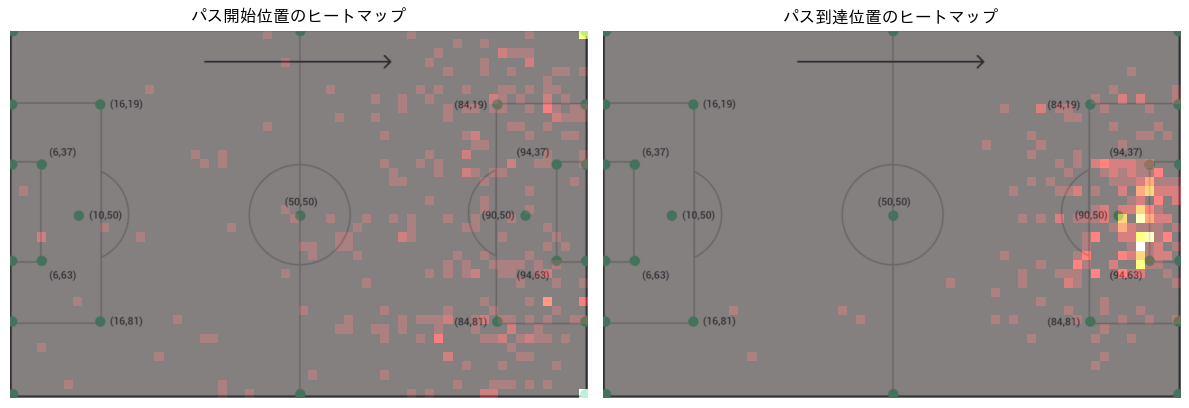

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg

# CSVファイルからデータの読み込み
pass_data = pd.read_csv("key-pass.csv", header=None, names=['start_x', 'start_y', 'end_x', 'end_y'])

# 背景画像の読み込み
img = mpimg.imread("/Users/saitoushu/Downloads/大学資料/未来創造/chancemake/soccer_court.png")

# 画像のサイズを取得
img_height = img.shape[0]
img_width = img.shape[1]

# グリッドのサイズを設定
grid_size = 20

# グリッドの数を計算
grid_rows = img_height // grid_size
grid_cols = img_width // grid_size

# grid_counts_startとgrid_counts_endを初期化
grid_counts_start = np.zeros((grid_rows, grid_cols))
grid_counts_end = np.zeros((grid_rows, grid_cols))

# ... (他のコードはそのまま)

# 各パスの開始位置と終了位置をグリッドに割り当て、カウント
for index, row in pass_data.iterrows():
    # 正規化された座標を画像上のピクセル座標に変換
    start_x = int(row['start_x'] / 100 * img_width)
    start_y = int(row['start_y'] / 100 * img_height)
    end_x = int(row['end_x'] / 100 * img_width)
    end_y = int(row['end_y'] / 100 * img_height)

    # 座標をグリッドのインデックスに変換 (画像の高さを考慮)
    grid_row_start = int(start_y / grid_size)
    grid_col_start = int(start_x / grid_size)  # 修正: img_width で割っていたのを grid_size で割る
    grid_row_end = int(end_y / grid_size)
    grid_col_end = int(end_x / grid_size)  # 修正: img_width で割っていたのを grid_size で割る
    
    # インデックスが範囲内であることを確認
    grid_row_start = min(grid_row_start, grid_rows - 1)
    grid_col_start = min(grid_col_start, grid_cols - 1)
    grid_row_end = min(grid_row_end, grid_rows - 1)
    grid_col_end = min(grid_col_end, grid_cols - 1)
    
    # カウントを増加
    grid_counts_start[grid_row_start, grid_col_start] += 1
    grid_counts_end[grid_row_end, grid_col_end] += 1

# ... (他のコードはそのまま)

# ヒートマップの描画 (開始位置)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

# extentの計算 (セルの境界が画像の境界と一致するように調整)
extent = [0, img_width, 0, img_height]

# 背景画像の設定 (開始位置)
ax[0].imshow(img, extent=extent)  
ax[0].imshow(grid_counts_start, cmap='hot', interpolation='nearest', 
           alpha=0.5, extent=extent)  
ax[0].set_title("パス開始位置のヒートマップ")
ax[0].axis('off')  # 軸の目盛を非表示にする

# 背景画像の設定 (到達位置)
ax[1].imshow(img, extent=extent)
ax[1].imshow(grid_counts_end, cmap='hot', interpolation='nearest', 
           alpha=0.5, extent=extent) 
ax[1].set_title("パス到達位置のヒートマップ")
ax[1].axis('off')  # 軸の目盛を非表示にする

plt.tight_layout()
plt.show()

In [167]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


クラスタ 0 (blue): 34 個
クラスタ 1 (red): 8 個
クラスタ 2 (green): 33 個
クラスタ 3 (orange): 7 個
クラスタ 4 (purple): 26 個
クラスタ 5 (brown): 63 個
クラスタ 6 (pink): 54 個
クラスタ 7 (gray): 4 個
クラスタ 8 (olive): 36 個
クラスタ 9 (cyan): 9 個


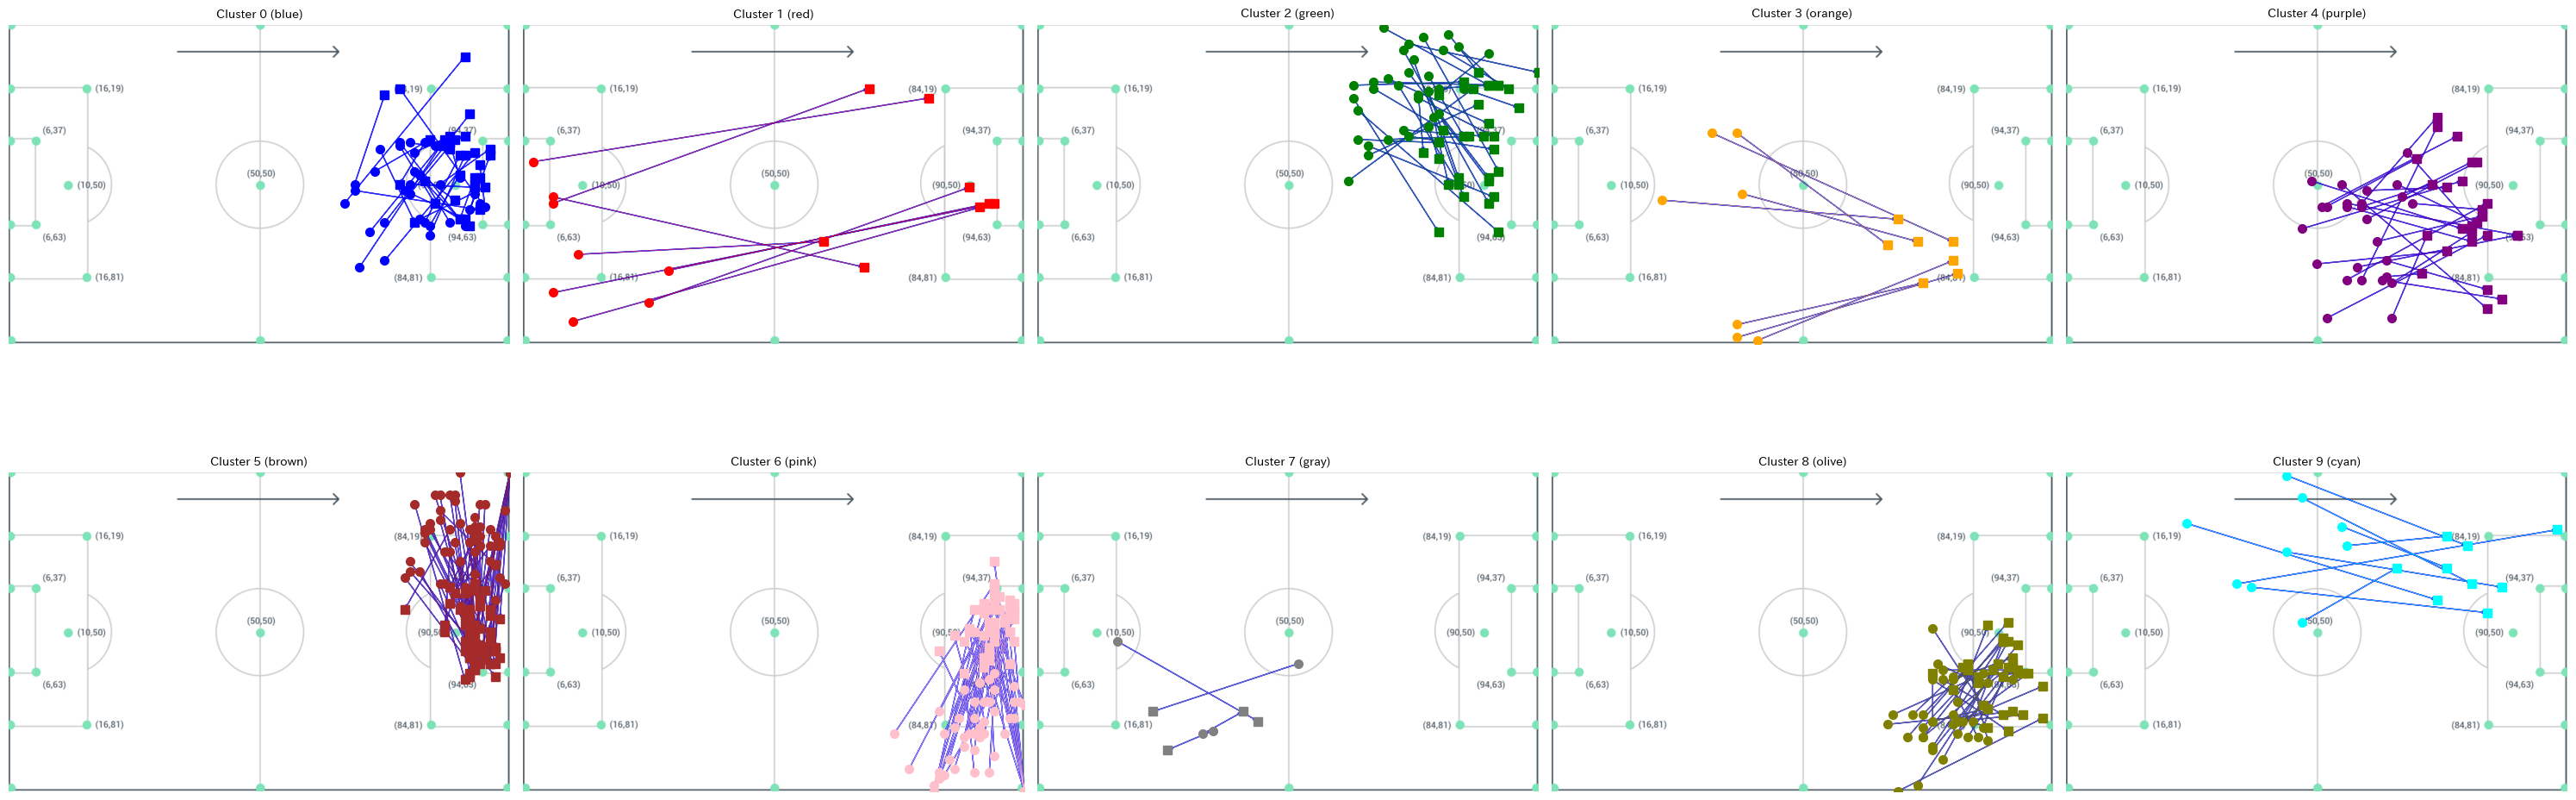

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.image as mpimg

# --- データの読み込み ---
pass_data = pd.read_csv("key-pass.csv", header=None, names=['start_x', 'start_y', 'end_x', 'end_y'])
length_interval = 5

# --- 画像関連の設定 ---
img_path = "/Users/saitoushu/Downloads/大学資料/未来創造/chancemake/soccer_court.png"
img = mpimg.imread(img_path)
img_height = img.shape[0]
img_width = img.shape[1]
img_aspect = img_width / img_height

# --- 線の座標をスケール変換 ---
pass_data['start_x'] = pass_data['start_x'] / 100 * img_width
pass_data['end_x'] = pass_data['end_x'] / 100 * img_width
pass_data['start_y'] = pass_data['start_y'] / 100 * img_height
pass_data['end_y'] = pass_data['end_y'] / 100 * img_height

# --- パスの長さ・方向を計算し、DataFrameに追加 ---
pass_data['pass_length'] = np.sqrt((pass_data['end_x'] - pass_data['start_x']) ** 2 + (pass_data['end_y'] - pass_data['start_y']) ** 2)

def classify_pass_direction(x_diff, y_diff):
    if x_diff > 0 and abs(y_diff) < x_diff:
        return "Right"
    elif x_diff < 0 and abs(y_diff) < abs(x_diff):
        return "Left"
    elif y_diff > 0 and abs(x_diff) < y_diff:
        return "Forward"
    else:
        return "Backward"

pass_data['pass_direction'] = pass_data.apply(lambda row: classify_pass_direction(row['end_x'] - row['start_x'], row['end_y'] - row['start_y']), axis=1)
pass_data['pass_length_category'] = (pass_data['pass_length'] // length_interval) * length_interval

# --- KMeansクラスタリング ---
n_clusters = 10  # クラスタ数を調整
kmeans = KMeans(n_clusters=n_clusters, random_state=0)

# 開始地点と到達地点の座標を特徴量として使用
features = pass_data[['start_x', 'start_y', 'end_x', 'end_y']]
pass_data['cluster'] = kmeans.fit_predict(features)

# --- FigureとAxesの準備 (アスペクト比を維持) --- 
fig, axes = plt.subplots(2, 5, figsize=(30, 12), facecolor='white') # 2行5列のグラフを作成

# --- 矢印のサイズ調整 ---
arrow_scale = 0.005  # 画像サイズに対する矢印の大きさの比率 (適宜調整)
head_width = img_width * arrow_scale 
head_length = img_width * arrow_scale * 2 

# --- クラスタごとに色分けして可視化 ---
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

# --- 各クラスタの数をカウント ---
cluster_counts = pass_data.groupby('cluster').size()

# --- 各クラスタの数を表示 ---
for cluster_id, count in cluster_counts.items():
    print(f"クラスタ {cluster_id} ({colors[cluster_id]}): {count} 個")

for cluster_id in range(n_clusters):
    cluster_data = pass_data[pass_data['cluster'] == cluster_id]
    ax = axes[cluster_id // 5, cluster_id % 5]  # 現在のクラスタに対応するAxesを選択
    ax.imshow(img, extent=[0, img_width, 0, img_height])
    ax.axis('off')
    ax.set_title(f"Cluster {cluster_id} ({colors[cluster_id]})", fontsize=10)  # タイトルにクラスタIDと色名を追加

    for index, row in cluster_data.iterrows():
        start_x = row['start_x']
        start_y = img_height - row['start_y']  # y座標を反転
        end_x = row['end_x']
        end_y = img_height - row['end_y']  # y座標を反転

        # 線の描画 
        ax.plot([start_x, end_x], [start_y, end_y], color=colors[cluster_id], linewidth=0.5, alpha=0.7)
        
        # 開始地点に丸マーカーを描画
        ax.plot(start_x, start_y, 'o', color=colors[cluster_id], markersize=7) 

        # 到達地点に四角マーカーを描画
        ax.plot(end_x, end_y, 's', color=colors[cluster_id], markersize=7)  

        # 矢印を描画 (サイズ調整)
        arrow_dx = end_x - start_x
        arrow_dy = end_y - start_y
        ax.arrow(start_x, start_y, arrow_dx, arrow_dy, 
                 head_width=head_width, head_length=head_length, 
                 fc='blue', ec='blue', length_includes_head=True, alpha=0.7) 

plt.tight_layout()
plt.show()

   start_x  start_y  end_x  end_y   distance  direction
0       11       72     60     68  49.162994  -4.666858
1       89        9     92     51  42.107007  85.914383
2       34       35     98     18  66.219333 -14.875682
3       98       23     96     43  20.099751  95.710593
4       84        7     92     19  14.422205  56.309932
   start_x  start_y  end_x  end_y   distance  direction  distance_group  \
0       11       72     60     68  49.162994  -4.666858               0   
1       89        9     92     51  42.107007  85.914383               0   
2       34       35     98     18  66.219333 -14.875682               0   
3       98       23     96     43  20.099751  95.710593               0   
4       84        7     92     19  14.422205  56.309932               0   

   direction_group  
0                3  
1                5  
2                3  
3                6  
4                5  
   distance_group  direction_group  count
0               0                0      1
1  

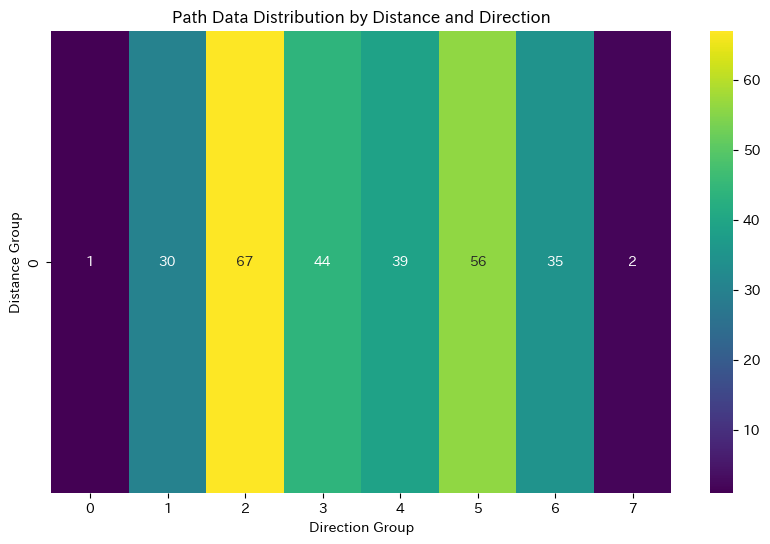

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- データの読み込み ---
pass_data = pd.read_csv("key-pass.csv", header=None, names=['start_x', 'start_y', 'end_x', 'end_y'])

def calculate_distance(row):
    start_x = row['start_x']
    start_y = row['start_y']
    end_x = row['end_x']
    end_y = row['end_y']
    return np.sqrt(((end_x - start_x) ** 2) + ((end_y - start_y) ** 2))

def calculate_direction(row):
    start_x = row['start_x']
    start_y = row['start_y']
    end_x = row['end_x']
    end_y = row['end_y']
    radians = np.arctan2(end_y - start_y, end_x - start_x)
    return np.degrees(radians) 

pass_data['distance'] = pass_data.apply(calculate_distance, axis=1)
pass_data['direction'] = pass_data.apply(calculate_direction, axis=1)

print(pass_data.head())

# --- 距離のビン分割 ---
distance_bins = [0, 100, 200, 300, float('inf')]  # 修正後のコード
pass_data['distance_group'] = pd.cut(pass_data['distance'], bins=distance_bins, labels=False, right=False)

# --- 方向のビン分割 ---
direction_bins = [-180, -135, -90, -45, 0, 45, 90, 135, 180]  # ビンの境界を設定
pass_data['direction_group'] = pd.cut(pass_data['direction'], bins=direction_bins, labels=False, right=False)

print(pass_data.head())

grouped_data = pass_data.groupby(['distance_group', 'direction_group']).size().reset_index(name='count')
print(grouped_data)

plt.figure(figsize=(10, 6))
sns.heatmap(grouped_data.pivot_table(index='distance_group', columns='direction_group', values='count'), 
            annot=True, cmap='viridis')
plt.xlabel('Direction Group')
plt.ylabel('Distance Group')
plt.title('Path Data Distribution by Distance and Direction')
plt.show()